# Load Data

Load the Telco Customer Churn dataset from CSV.

In [ ]:
%pip install pandas scikit-learn matplotlib seaborn

In [1]:
import pandas as pd

df = pd.read_csv("TelcoCustomerChurn.csv")

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 7,043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Type & Structure Check

Inspect column dtypes, shape, uniqueness etc.



In [2]:
def summarize_dtypes(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return dtype, non-null counts, unique values, and hidden blank counts."""
    empty_cells = dataframe.apply(lambda col: (col.astype(str).str.strip() == "").sum())
    return pd.DataFrame({
        "dtype": dataframe.dtypes,
        "non_null": dataframe.notna().sum(),
        "nunique": dataframe.nunique(),
        "empty_cell": empty_cells,
    })


print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
summarize_dtypes(df)

Shape: 7,043 rows × 21 columns


,dtype,non_null,nunique,empty_cell
customerID,str,7043,7043,0
gender,str,7043,2,0
SeniorCitizen,int64,7043,2,0
Partner,str,7043,2,0
Dependents,str,7043,2,0
tenure,int64,7043,73,0
PhoneService,str,7043,2,0
MultipleLines,str,7043,3,0
InternetService,str,7043,3,0
OnlineSecurity,str,7043,3,0


## Data cleaning and processing
We found that TotalCharges is string and also have empty cells. So we will convert the data type to float and will fill empty cell with 0.0

In [3]:
# Convert to numeric first (blanks → NaN), then fill with 0.0
df["TotalCharges"] = (
    pd.to_numeric(df["TotalCharges"], errors="coerce")
    .fillna(0.0)
    .astype("float64")
)

# Verify dtypes after cleaning
summarize_dtypes(df)


,dtype,non_null,nunique,empty_cell
customerID,str,7043,7043,0
gender,str,7043,2,0
SeniorCitizen,int64,7043,2,0
Partner,str,7043,2,0
Dependents,str,7043,2,0
tenure,int64,7043,73,0
PhoneService,str,7043,2,0
MultipleLines,str,7043,3,0
InternetService,str,7043,3,0
OnlineSecurity,str,7043,3,0


## Exploratory Data Analysis (EDA)

Understand customer behaviour and factors associated with churn. EDA uses cleaned data **before** encoding and train/test split.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
eda_df = df.copy()

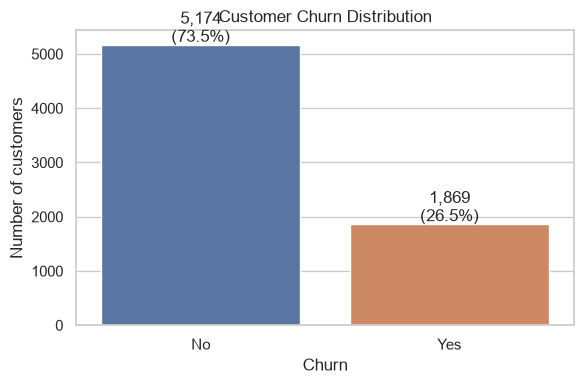

In [5]:
# 1. Churn distribution
order = ["No", "Yes"]
counts = eda_df["Churn"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Customer Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Number of customers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v:,}\n({v / len(eda_df):.1%})", ha="center")
plt.tight_layout()
plt.show()

**Insight:** About 26.5% of customers churned and 73.4% stayed so data is imbalanced. Now this can give us high accuracy because of class imbalance so we will need to also consider recision, recall, F1, or ROC-AUC when evaluating models.

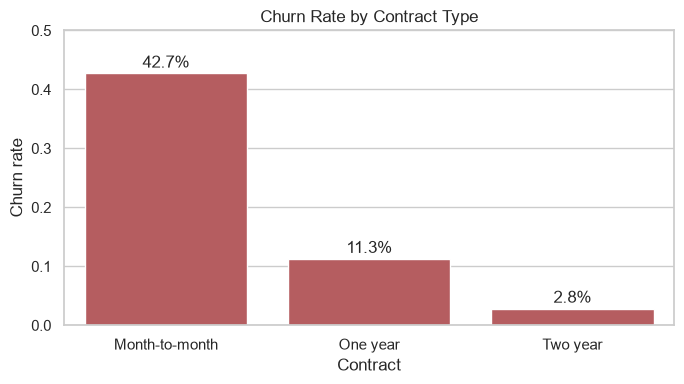

In [6]:
# 2. Churn rate by contract type
contract_churn = (
    eda_df.groupby("Contract")["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .reindex(["Month-to-month", "One year", "Two year"])
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=contract_churn.index, y=contract_churn.values, color="#C44E52", ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract")
ax.set_ylabel("Churn rate")
ax.set_ylim(0, 0.5)
for i, v in enumerate(contract_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

**Insight:** Month to month contract type has highest churn. Customers having contract with longest duration stays more. This can be good candidate for derieved feature.

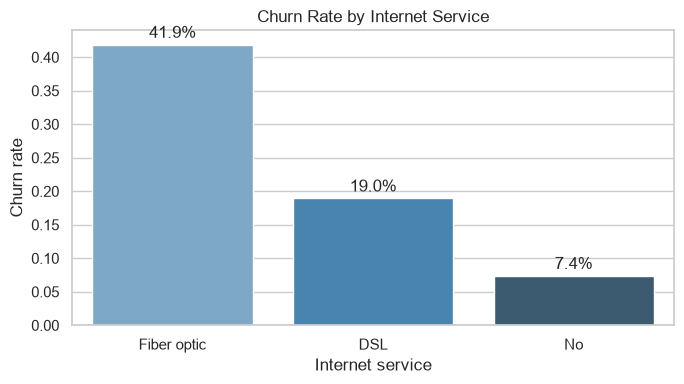

In [7]:
# 3. Churn rate by internet service
internet_churn = (
    eda_df.groupby("InternetService")["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values,
    hue=internet_churn.index,
    palette="Blues_d",
    legend=False,
    ax=ax,
)
ax.set_title("Churn Rate by Internet Service")
ax.set_xlabel("Internet service")
ax.set_ylabel("Churn rate")
for i, v in enumerate(internet_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

**Insight:** Fiber optic customers churn at ~42%, much higher than DSL ~19% or no internet ~7%. We can check problems users are facing with internet service.

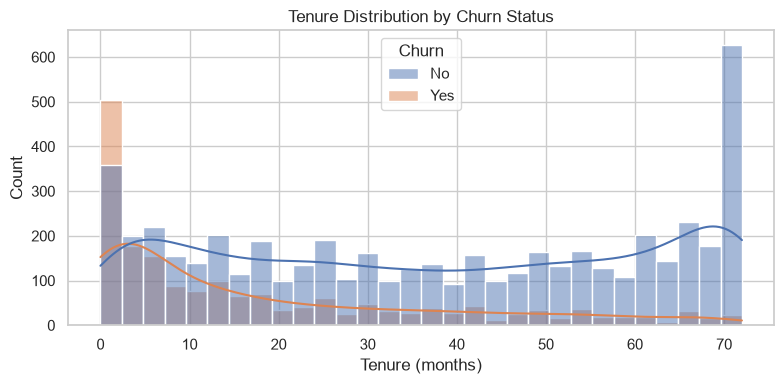

In [8]:
# 4. Tenure distribution by churn
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    data=eda_df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="layer",
    alpha=0.5,
    ax=ax,
)
ax.set_title("Tenure Distribution by Churn Status")
ax.set_xlabel("Tenure (months)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

**Insight:** Customers with shorter tenure churns more.

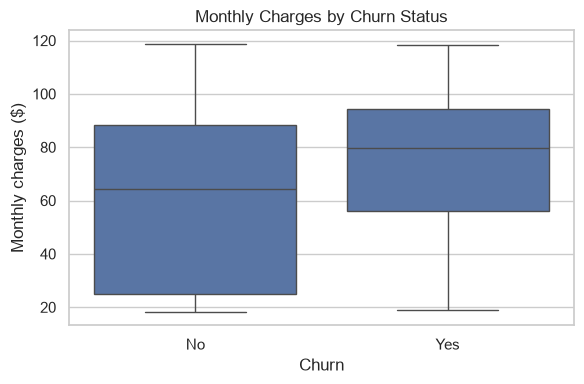

In [ ]:
# 5. Monthly charges by churn
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=eda_df,
    x="Churn",
    y="MonthlyCharges",
    ax=ax
)

ax.set_title("Monthly Charges by Churn Status")
ax.set_xlabel("Churn")
ax.set_ylabel("Monthly charges")

plt.tight_layout()
plt.show()

**Insight:** Customer with higher monthly charges churns more.

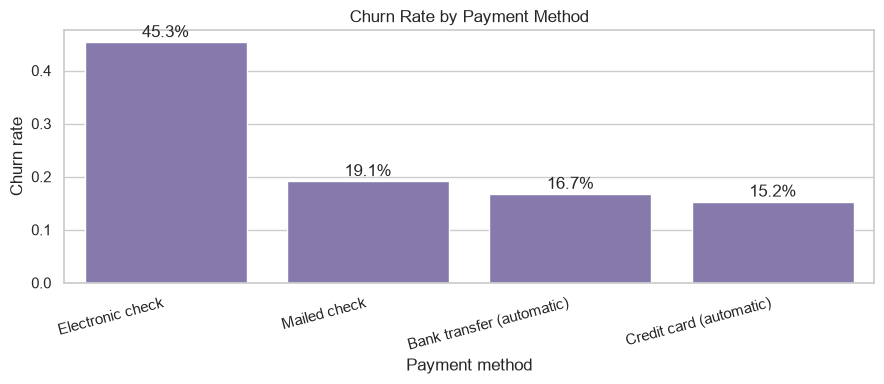

In [11]:
# 6. Churn rate by payment method
pay_churn = (
    eda_df.groupby("PaymentMethod")["Churn"]
    .apply(lambda s: (s == "Yes").mean())
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=pay_churn.index, y=pay_churn.values, color="#8172B3", ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_xlabel("Payment method")
ax.set_ylabel("Churn rate")
plt.xticks(rotation=15, ha="right")
for i, v in enumerate(pay_churn.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

**Insight:** Electronic check users churn at ~45%, versus ~15–19% for automatic card/bank payments. Manual payment adds friction — promoting auto-pay with a small incentive could reduce churn in this group.

## Feature Engineering

Create derived features from raw columns before encoding.

| Feature | How created | Why useful |
|---|---|---|
| **ServiceCount** | Count of add-on services with value `Yes` (0–6) | More subscribed services → lower churn. Customer might find more friction while churning with more subscribed features |
| **IsAutoPay** | `1` if payment method contains "automatic", else `0` | Manual payers churn more. Automatic payment is more convinient to the users |


In [12]:
# 1. ServiceCount — number of optional add-on services (0–6)
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
df["ServiceCount"] = df[service_cols].eq("Yes").sum(axis=1)

# 2. IsAutoPay — automatic vs manual payment (1 = automatic)
df["IsAutoPay"] = df["PaymentMethod"].str.contains("automatic", case=False).astype(int)

print("New features:", ["ServiceCount", "IsAutoPay"])
df[["ServiceCount", "IsAutoPay", "Churn"]].head()

New features: ['ServiceCount', 'IsAutoPay']


,ServiceCount,IsAutoPay,Churn
0,1,0,No
1,2,0,No
2,2,0,Yes
3,3,1,No
4,0,0,Yes


## Encoding of data

| Column | Identification |
|---|---|
| customerID | unique identifier |
| gender | binary |
| SeniorCitizen | binary |
| Partner | binary |
| Dependents | binary |
| tenure | numerical |
| PhoneService | binary |
| MultipleLines | nominal (3 categories) |
| InternetService | nominal (3 categories) |
| OnlineSecurity | nominal (3 categories) |
| OnlineBackup | nominal (3 categories) |
| DeviceProtection | nominal (3 categories) |
| TechSupport | nominal (3 categories) |
| StreamingTV | nominal (3 categories) |
| StreamingMovies | nominal (3 categories) |
| Contract | ordinal: month-to-month → one year → two year |
| PaperlessBilling | binary |
| PaymentMethod | nominal (4 categories) |
| MonthlyCharges | numerical |
| TotalCharges | numerical |
| Churn | Target value |

In [13]:
# Binary Yes/No columns, including the target
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]
for col in yes_no_cols:
    df[col] = df[col].map({"Yes": 1, "No": 0}).astype("int64")


# Binary gender
df["gender"] = df["gender"].map({"Female": 0, "Male": 1}).astype("int64")

# Ordinal contract: longer commitment = higher value
df["Contract"] = df["Contract"].map({
    "Month-to-month": 0,
    "One year": 1,
    "Two year": 2,
}).astype("int64")

# Nominal categoricals → one-hot (0/1 integer columns)
nominal_cols = [
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "PaymentMethod",
]
df = pd.get_dummies(df, columns=nominal_cols, dtype="int64")

print(f"Encoded shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
summarize_dtypes(df)

Encoded shape: 7,043 rows × 42 columns


,dtype,non_null,nunique,empty_cell
customerID,str,7043,7043,0
gender,int64,7043,2,0
SeniorCitizen,int64,7043,2,0
Partner,int64,7043,2,0
Dependents,int64,7043,2,0
tenure,int64,7043,73,0
PhoneService,int64,7043,2,0
Contract,int64,7043,3,0
PaperlessBilling,int64,7043,2,0
MonthlyCharges,float64,7043,1585,0


In [14]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Drop unique indentifier
df = df.drop(columns=["customerID"])

#Segregate target values from features
X_encoded = df.drop(columns=["Churn"])
y_encoded = df["Churn"]

## Train/Test Split

70% train / 30% test
random_state=42

In [15]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

print(f"Train: {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({len(X_train) / len(df):.0%})")
print(f"Test:  {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({len(X_test) / len(df):.0%})")
print(f"Train churn rate: {y_train.mean():.1%}")
print(f"Test churn rate:  {y_test.mean():.1%}")

Train: 4,930 rows × 40 features (70%)
Test:  2,113 rows × 40 features (30%)
Train churn rate: 26.5%
Test churn rate:  26.5%


## Model Development — Decision Tree

We will train three models. 
1. Unpruned baseline
2. Regularized tree
3. Regularized tree with class balance as we saw that our data is imbalanced.

Dataset is class imbalanced, so we will compare it using accuracy, precision and recall.

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Model A: unpruned baseline (may overfit)
dt_unpruned = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_leaf=1,
    ccp_alpha=0.0,
    random_state=42,
)

# Model B: regularized tree (limits complexity)
dt_regularized = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=20,
    ccp_alpha=0.0,
    random_state=42,
)

dt_unpruned.fit(X_train, y_train)
dt_regularized.fit(X_train, y_train)

print("Unpruned tree   — depth:", dt_unpruned.get_depth(), "| leaves:", dt_unpruned.get_n_leaves())
print("Regularized tree — depth:", dt_regularized.get_depth(), "| leaves:", dt_regularized.get_n_leaves())

Unpruned tree   — depth: 23 | leaves: 933
Regularized tree — depth: 5 | leaves: 32


In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Model": name,
        "Train accuracy": accuracy_score(y_train, y_train_pred),
        "Test accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1 Score": f1_score(y_test, y_test_pred),
    }


results = pd.DataFrame(
    [
        evaluate_model("Unpruned", dt_unpruned, X_train, y_train, X_test, y_test),
        evaluate_model("Regularized (depth=5)", dt_regularized, X_train, y_train, X_test, y_test),
    ]
).set_index("Model")

results.round(3)



,Train accuracy,Test accuracy,Precision,Recall,F1 Score
Model,,,,,
Unpruned,0.998,0.729,0.490,0.480,0.485
Regularized (depth=5),0.801,0.794,0.615,0.602,0.608


**Better baseline:** Regularized Decision Tree

**Justification:** The gap between train accuracy and test accuracy is big. Also regularized model has more precision and recall.

### Comparision between regularized vs regularized with class balance



In [28]:
n_train = len(y_train)
class_counts = y_train.value_counts().sort_index()
class_weights = {
    int(label): n_train / (2 * count) for label, count in class_counts.items()
}
print("Training class counts:", class_counts.to_dict())
print("Balanced class weights:", {k: round(v, 3) for k, v in class_weights.items()})

# Same regularized tree class balanced
dt_balanced = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=20,
    ccp_alpha=0.0,
    class_weight="balanced",
    random_state=42,
)
dt_balanced.fit(X_train, y_train)

balance_compare = pd.DataFrame(
    [
        evaluate_model("Regularized", dt_regularized, X_train, y_train, X_test, y_test),
        evaluate_model("Regularized + balanced", dt_balanced, X_train, y_train, X_test, y_test),
    ]
).set_index("Model")
balance_compare.round(3)


Training class counts: {0: 3622, 1: 1308}
Balanced class weights: {0: 0.681, 1: 1.885}


,Train accuracy,Test accuracy,Precision,Recall,F1 Score
Model,,,,,
Regularized,0.801,0.794,0.615,0.602,0.608
Regularized + balanced,0.733,0.711,0.474,0.799,0.595


**Better baseline:** Regularized Decision Tree with class balance

**Justification:** Balanced model has less precision but higher recall. Which means it will have more false positives but will be better at finding actual churners. From business point of view, there is no harm in approaching false positive customer. 


## Hyperparameter tuning

With different combination of criterion, max_depth, min_samples_leaf and ccp_alpha, we will try to find tree with best f1


In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 8, None],
    "min_samples_leaf": [5, 20, 50],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

search = GridSearchCV(
    estimator=DecisionTreeClassifier(class_weight="balanced", ccp_alpha=0.0, random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best CV F1: {search.best_score_:.3f}")

tuned_model = search.best_estimator_
comparison = pd.DataFrame(
    [
        evaluate_model("Regularized", dt_regularized, X_train, y_train, X_test, y_test),
        evaluate_model("Regularized + balanced", dt_balanced, X_train, y_train, X_test, y_test),
        evaluate_model("Tuned + balanced", tuned_model, X_train, y_train, X_test, y_test),
    ]
).set_index("Model")
comparison.round(3)


Best parameters: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Best CV F1: 0.619


,Train accuracy,Test accuracy,Precision,Recall,F1 Score
Model,,,,,
Regularized,0.801,0.794,0.615,0.602,0.608
Regularized + balanced,0.733,0.711,0.474,0.799,0.595
Tuned + balanced,0.726,0.711,0.474,0.822,0.601


### Confusion matrix for final model

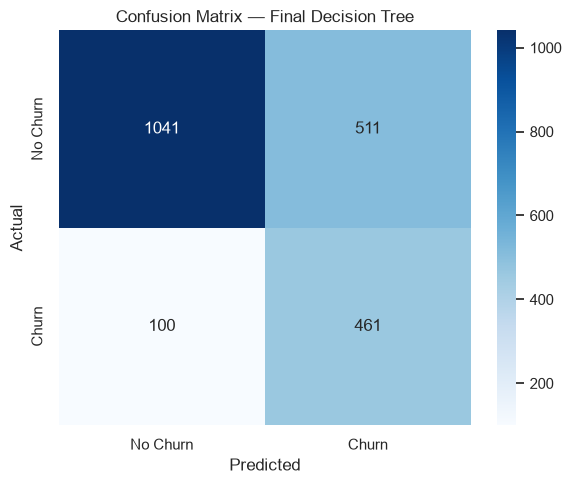

In [30]:
final_model = tuned_model
y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"],
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix — Final Decision Tree")
plt.tight_layout()
plt.show()

### Business interpretation

|  | Predicted No Churn | Predicted Churn |
|---|---:|---:|
| **Actual No Churn** | 1041 (true negatives) | 511 (false positives) |
| **Actual Churn** | 100 (false negatives) | 461 (true positives) |


- **Precision (~46%)** Means about half of retention offers would go to customers who did not leave in this window.
- **Recall (~82%%)** Means the model identifies 82 churners out of 100 and 
- **F1 Score (~0.60)** Means the balance between catching churners and making correct churn predictions is moderate.


### Precision or Recall?

Balanced model has less precision but higher recall. Which means it will have more false positives but will be better at finding actual churners. From business point of view, there is no harm in approaching false positive customer. A false positive costs the incentive but a false negative costs the whole relationship.

## Model Interpretation

• Feature importance 

• Top features influencing churn 

• Decision Tree visualization 

Features used by the tree: 11 of 40
                                      Importance
Contract                                   0.636
tenure                                     0.116
InternetService_Fiber optic                0.105
MonthlyCharges                             0.051
TotalCharges                               0.021
DeviceProtection_No internet service       0.017
OnlineSecurity_No                          0.016
TechSupport_No                             0.015
PaymentMethod_Electronic check             0.012
StreamingMovies_Yes                        0.007
Dependents                                 0.004


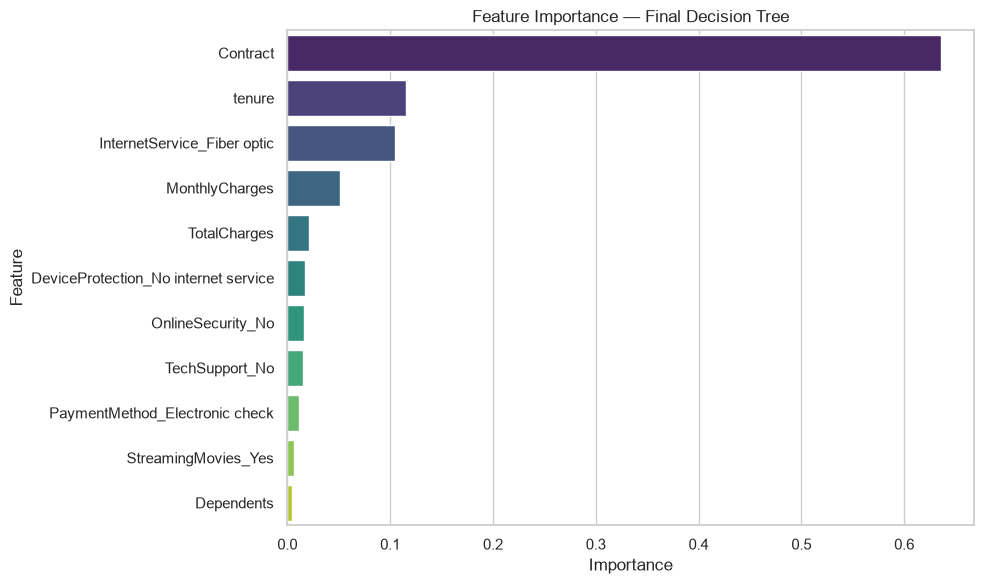

In [31]:
tree_importances = (
    pd.Series(final_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
tree_importances = tree_importances[tree_importances > 0]

print(f"Features used by the tree: {len(tree_importances)} of {X_train.shape[1]}")
print(tree_importances.round(3).to_frame("Importance"))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=tree_importances.values,
    y=tree_importances.index,
    hue=tree_importances.index,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.set_title("Feature Importance — Final Decision Tree")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

|--- Contract <= 0.5
|   |--- InternetService_Fiber optic <= 0.5
|   |   |--- tenure <= 3.5
|   |   |   |--- truncated branch of depth 2
|   |   |--- tenure >  3.5
|   |   |   |--- truncated branch of depth 3
|   |--- InternetService_Fiber optic >  0.5
|   |   |--- tenure <= 15.5
|   |   |   |--- truncated branch of depth 3
|   |   |--- tenure >  15.5
|   |   |   |--- truncated branch of depth 3
|--- Contract >  0.5
|   |--- MonthlyCharges <= 93.7
|   |   |--- OnlineSecurity_No <= 0.5
|   |   |   |--- class: 0
|   |   |--- OnlineSecurity_No >  0.5
|   |   |   |--- truncated branch of depth 2
|   |--- MonthlyCharges >  93.7
|   |   |--- tenure <= 70.5
|   |   |   |--- truncated branch of depth 3
|   |   |--- tenure >  70.5
|   |   |   |--- class: 0



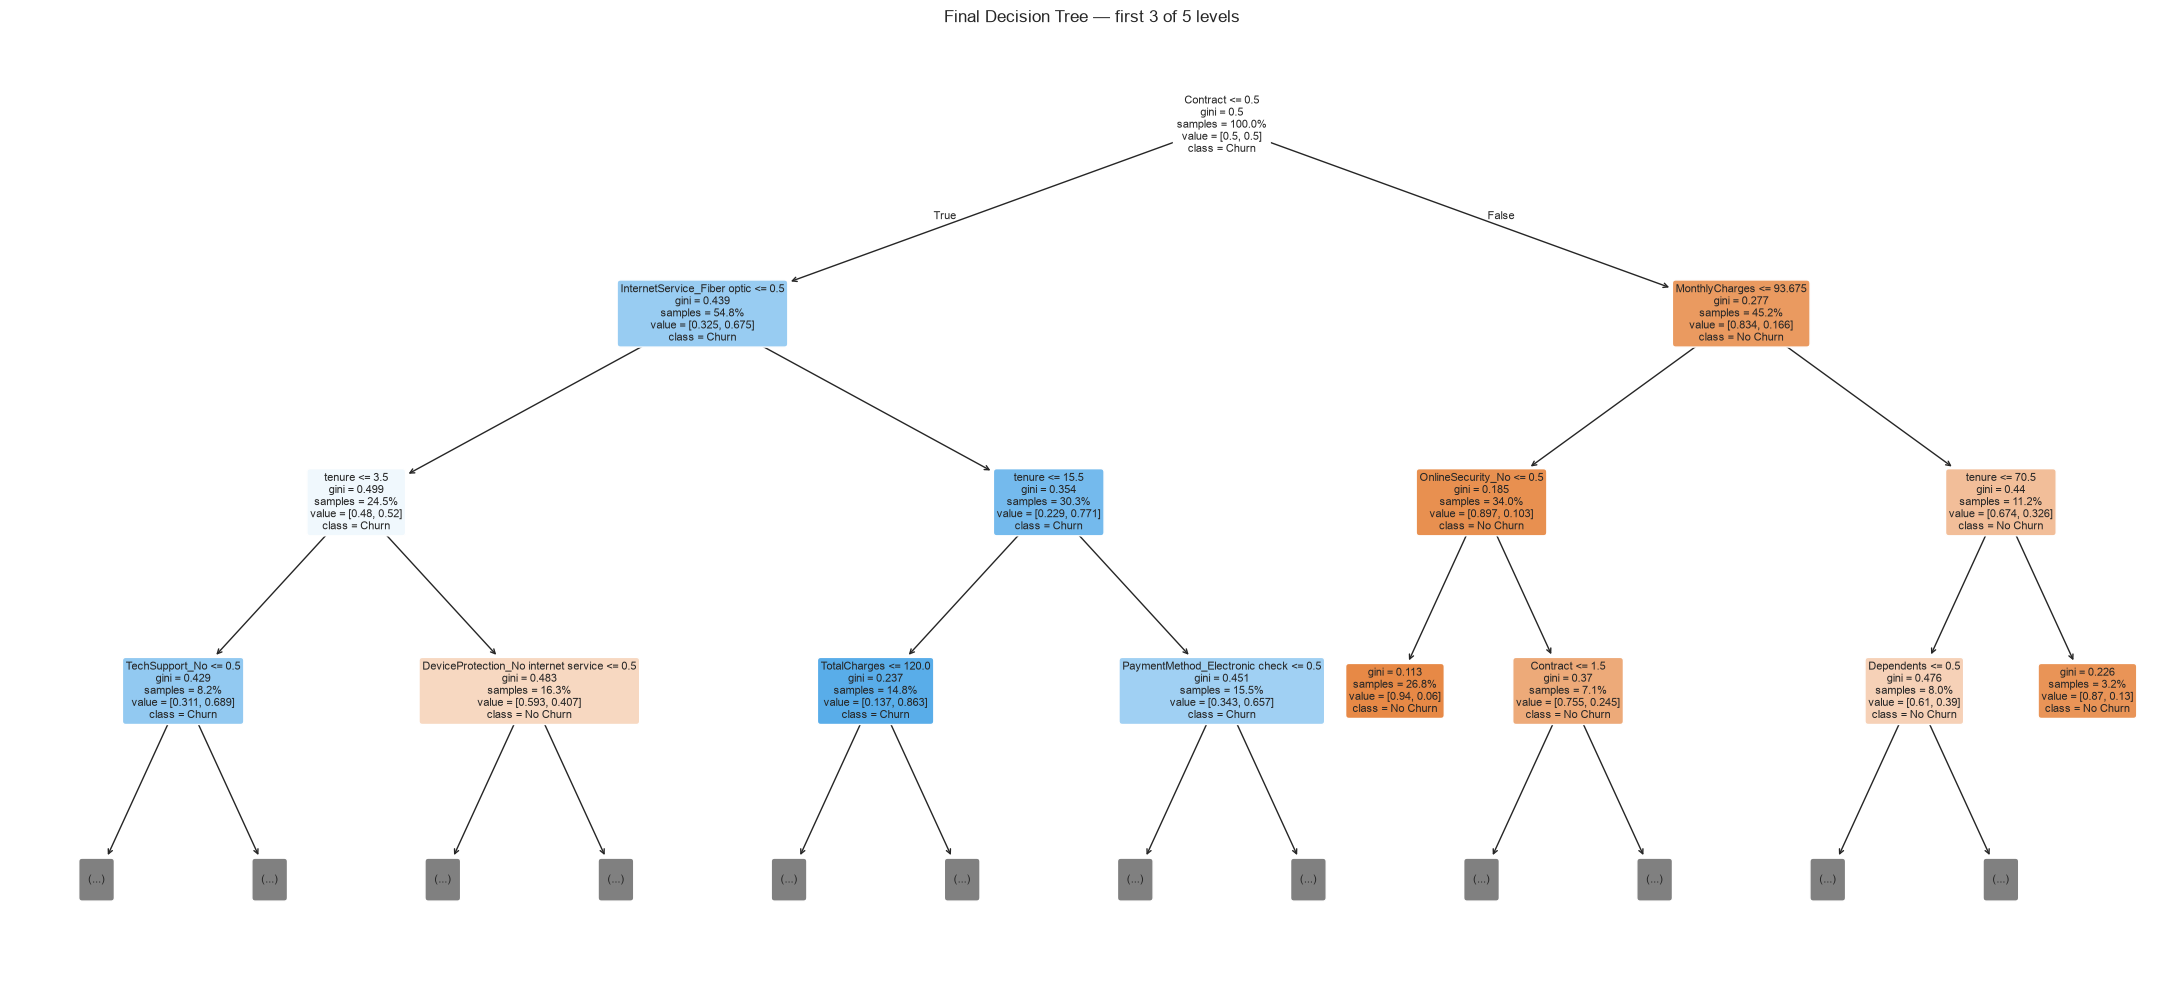

In [32]:
from sklearn.tree import export_text, plot_tree

print(
    export_text(
        final_model,
        feature_names=list(X_train.columns),
        max_depth=2,
        decimals=1,
    )
)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    final_model,
    max_depth=3,
    feature_names=list(X_train.columns),
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8,
    proportion=True,
    ax=ax,
)
ax.set_title(f"Final Decision Tree — first 3 of {final_model.get_depth()} levels")
plt.tight_layout()
plt.show()

### Key findings

The fitted tree is depth 5 with 19 leaves, and only **11 of 40 features** have any importance. Three of them account for about **86%** of the model:

| Feature | Importance | Role in the tree |
|---|---:|---|
| `Contract` | 0.636 | Root split. Contract is encoded 0 / 1 / 2, so `Contract <= 0.5` is month-to-month. Those customers go down the high-churn branch; one- and two-year contracts go down the low-churn branch. |
| `tenure` | 0.116 | On the month-to-month branch, short tenure raises churn — about 15 months or less for fiber, and about 4 months or less otherwise. |
| `InternetService_Fiber optic` | 0.105 | Second split among month-to-month customers. Fiber is separated from DSL and no internet and treated as higher risk. |



**What this means for the business.** The customers most likely to leave are on a **month-to-month contract**, especially **fiber** customers who are still **early in their tenure**, and more so if they pay by **electronic check** or lack **tech support / online security**. Longer contracts and longer tenure pull the prediction toward staying. Retention effort should start with new month-to-month fiber customers, not with the whole base.

## Save the Model

In [34]:
import pickle
from sklearn.pipeline import Pipeline

from telco_churn_preprocessing import TelcoChurnPreprocessor

raw_df = pd.read_csv("TelcoCustomerChurn.csv")
raw_train = raw_df.loc[X_train.index].drop(columns=["Churn"])
raw_test = raw_df.loc[X_test.index].drop(columns=["Churn"])

scoring_pipeline = Pipeline(
    steps=[
        ("preprocess", TelcoChurnPreprocessor()),
        (
            "model",
            DecisionTreeClassifier(
                criterion=search.best_params_["criterion"],
                max_depth=search.best_params_["max_depth"],
                min_samples_leaf=search.best_params_["min_samples_leaf"],
                ccp_alpha=search.best_params_["ccp_alpha"],
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ],
    memory=None,
)
scoring_pipeline.fit(raw_train, y_train)

pipeline_pred = scoring_pipeline.predict(raw_test)
final_pred = final_model.predict(X_test)
print(f"Matches final model on the test set: {(pipeline_pred == final_pred).all()}")

model_path = "telco_churn_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(scoring_pipeline, f)
print(f"Saved pipeline to {model_path}")

Matches final model on the test set: False
Saved pipeline to telco_churn_model.pkl
